# Accommodation scan: validation and coefficient profiles

Load saved conditional mean-curvature models without fitting. Each model predicts deviations from an organoid's **measured mean**, optionally expressed in units of its **measured SD**. Models never receive measured node curvatures; the measured summaries enter only target construction and physical reconstruction. This is a conditional allocation task, not fate-only prediction of an unknown organoid shape.

Settings and model selection appear immediately below the imports. Validation MSE is averaged over cells **within each organoid**, then over organoids within each fold, and finally over folds. Overall MSE covers ordinary validation; the combined spherical-like/no-detected-crypt category also includes held-out spherical organoids. These are repeated across fold models, not independent new cohorts. Unqualified boundary cells remain in overall MSE and are omitted from regional panels. Fold SEM describes variation among these fitted models and is not a full uncertainty interval.

Only the requested accommodation-dependent MSE, center preferences and ordered-pair amplitudes are retained. Each pair gets its own panel; normalization modes use separate coefficient figures because their units differ.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from scipy.sparse import csr_matrix, diags, eye
from scipy.sparse.linalg import factorized
from scipy.sparse.csgraph import shortest_path
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))
from src.artifacts.bundle import load_bundle
from src.data.target_transforms import center_graph_values
from src.training.coupled_fit import graph_samples
from src.analysis.metrics.conditional import conditional_region_scores
from src.data.synthetic import triangular_lattice_edges


## Settings
Choose the completed run, normalization and model selection. All plotted quantities are reconstructed from its saved checkpoints and prediction archives.

In [2]:
# Saved models and target definition
TRAINING_RUN = 'training_results/energy_model_training/conditional_scan_20261002_162217'  # Completed training folder; exact models and folds are restored.
TARGET_MODES = ['mean_only', 'standardized']  # Mean subtraction or mean+SD standardization.
VARIANTS = ['presence_energy']  # Selected model names; None compares all configured variants.
GAMMA = None  # None: entire saved scan; otherwise one fixed energy accommodation.

# Evaluation and figures
REGIONS = ['total', 'crypt_with_LGR5', 'crypt_without_LGR5', 'neck', 'villus', 'spherical_or_no_detected_crypt']  # Overall ordinary validation and anatomical categories.
MSE_METRICS = ['mse', 'standardized_mse']  # Physical and SD-normalized MSE, comparable across training definitions.
OUTPUT_TAG = 'accommodation_profiles'  # Outputs under the selected run's analysis folder.


## Restore and verify
Validate organoid membership, node-aligned targets and region labels. Check target-free checkpoint inference against saved predictions. Export per-organoid, per-fold and summary scores; restore coefficient tables directly from fitted models.

In [3]:
run=Path(TRAINING_RUN)
if not run.is_absolute():run=PROJECT_ROOT/run
if not (run/'complete.json').exists():raise ValueError('Choose a completed run.')
settings=json.loads((run/'settings.json').read_text())
records=pd.read_json(run/'models.json')
membership=json.loads((run/'splits.json').read_text())
regions=pd.read_csv(run/'regions.csv.gz')
region_by_id={str(oid):g.sort_values('node').region.to_numpy() for oid,g in regions.groupby('organoid_str')}
OUTPUT_DIR=run/'analysis'/OUTPUT_TAG;OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
# Selection is explicit; no model is selected on outer-validation MSE here.
selected=records[records.target_mode.isin(TARGET_MODES)].copy()
if VARIANTS is not None:selected=selected[selected.variant.isin(VARIANTS)]
if GAMMA is not None:selected=selected[(selected.family=='gin')|np.isclose(selected.gamma,float(GAMMA))]
if selected.empty:raise ValueError('No models match the requested settings.')
selected.to_csv(OUTPUT_DIR/'models.csv',index=False)
(OUTPUT_DIR/'settings.json').write_text(json.dumps(dict(training_run=str(run),modes=TARGET_MODES,variants=VARIANTS,gamma=GAMMA,regions=REGIONS),indent=2))
metric_rows=[];coefficient_rows=[];verification=[]
for fold,fold_records in selected.groupby('fold'):
    data=load_bundle(run/f'inputs/fold_{fold}_mean');identities=data['marker_names']+['Unassigned']
    split=next(s for s in membership if s['fold']==fold)
    if [str(g.organoid_str) for g in data['physical_groups']['val']]!=split['validation']:raise ValueError('Validation membership differs.')
    reference_added=set()
    for rec in fold_records.itertuples():
        payload=load_bundle(run/rec.bundle);model=payload['model']
        if payload['metrics']['fit_organoids']!=split['train']:raise ValueError('Fitted membership differs.')
        if rec.family=='energy':
            if not model.zero_mean_output or model.fixed_strength!=rec.gamma:raise ValueError('Wrong energy configuration.')
            coef=model.coefficients([1])
            for a,A in enumerate(identities):
                coefficient_rows.append(dict(key=rec.key,fold=fold,target_mode=rec.target_mode,variant=rec.variant,gamma=rec.gamma,
                    family='center',recipient=A,source='',value=float(coef['center'][0,a]),support=len(split['train'])))
                if model.pairs:
                    allowed=np.any(np.abs(model.array(model.contrast))>0,axis=1).reshape(len(identities),len(identities))
                    for b,B in enumerate(identities):
                        coefficient_rows.append(dict(key=rec.key,fold=fold,target_mode=rec.target_mode,variant=rec.variant,gamma=rec.gamma,
                            family='interaction',recipient=A,source=B,value=float(coef['amplitude'][0,a,b]),
                            included=bool(allowed[a,b]),support=int(model.pair_support[a,b])))
        for role in ['val','spherical']:
            graphs=data['physical_groups'][role]
            if not graphs:continue
            with np.load(run/'predictions'/f'{rec.key}_{role}.npz',allow_pickle=False) as archive:
                if list(archive['organoid_ids'])!=[str(g.organoid_str) for g in graphs]:raise ValueError('Prediction IDs differ.')
                truth=np.concatenate([g.y.numpy().reshape(-1) for g in graphs])
                np.testing.assert_allclose(archive['truth'],truth,rtol=0,atol=1e-12)
                frame=conditional_region_scores(archive,region_by_id,data['moments'],cohort=role,include_mean_reference=role not in reference_added)
                frame['fold']=fold
                for col in ['key','target_mode','variant','gamma']:frame[col]=getattr(rec,col)
                ref=frame.is_reference
                frame.loc[ref,'key']='measured_mean';frame.loc[ref,'target_mode']='reference';frame.loc[ref,'variant']='measured_mean';frame.loc[ref,'gamma']=np.nan
                metric_rows.append(frame);reference_added.add(role)
                # One target-free restored graph per checkpoint/cohort certifies inference conventions.
                graph=graphs[0].clone();mom=data['moments'][str(graph.organoid_str)]
                if rec.family=='energy':
                    sample=graph_samples([graph],2)[0];sample.pop('y')
                    pred=model.predict_sample(sample)
                else:
                    del graph['y'];model.cpu().eval()
                    batch=next(iter(DataLoader([Data(x=graph.x,edge_index=graph.edge_index)],batch_size=1)))
                    with torch.no_grad():
                        (mu,_),_=model(batch.x,batch.edge_index,data=batch)
                        pred=center_graph_values(mu.reshape(-1),batch.batch).numpy()
                physical=mom.mean+(mom.scale if rec.target_mode=='standardized' else 1.)*pred
                saved=archive['prediction'][:len(graph.x)]
                error=float(np.max(np.abs(physical-saved)))
                if error>2e-6:raise ValueError(f'Restored inference differs: {rec.key}: {error}')
                verification.append(dict(key=rec.key,cohort=role,max_difference=error))
metrics=pd.concat(metric_rows,ignore_index=True)
coefficients=pd.DataFrame(coefficient_rows)
fold_scores=metrics.groupby(['target_mode','variant','gamma','region','fold'],dropna=False).agg(
    mse=('mse','mean'),standardized_mse=('standardized_mse','mean'),organoids=('organoid_str','nunique'),cells=('cells','sum')).reset_index()
summary=fold_scores.groupby(['target_mode','variant','gamma','region'],dropna=False).agg(
    mse=('mse','mean'),mse_sem=('mse','sem'),standardized_mse=('standardized_mse','mean'),standardized_sem=('standardized_mse','sem')).reset_index()
for name,frame in [('organoid_scores',metrics),('fold_scores',fold_scores),('summary',summary),('coefficients',coefficients),('restoration_checks',pd.DataFrame(verification))]:
    frame.to_csv(OUTPUT_DIR/f'{name}.csv',index=False)
mode_labels={'mean_only':'Mean only','standardized':'Mean + SD','reference':'Measured mean'}
mode_colors={'mean_only':'tab:orange','standardized':'tab:blue','reference':'black'}
region_labels={'total':'Overall (ordinary validation)','crypt_with_LGR5':'Crypt with LGR5','crypt_without_LGR5':'Crypt without LGR5',
               'neck':'Qualified neck','villus':'Villus','spherical_or_no_detected_crypt':'Spherical-like / no detected crypt'}
def save_figure(fig,name):
    fig.savefig(OUTPUT_DIR/f'{name}.png',dpi=160,bbox_inches='tight');plt.show()
print('Loaded',len(selected),'models from',run.name)


/tmp/ipykernel_2346602/314991230.py:7: DtypeWarning: Columns (5,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  regions=pd.read_csv(run/'regions.csv.gz')


Loaded 110 models from conditional_scan_20261002_162217


## Validation MSE
Show overall and regional errors in physical and SD-normalized curvature units. Small points or thin lines denote folds; thick markers/lines denote means with SEM. The dashed measured-mean reference uses the same cells and organoid weights.

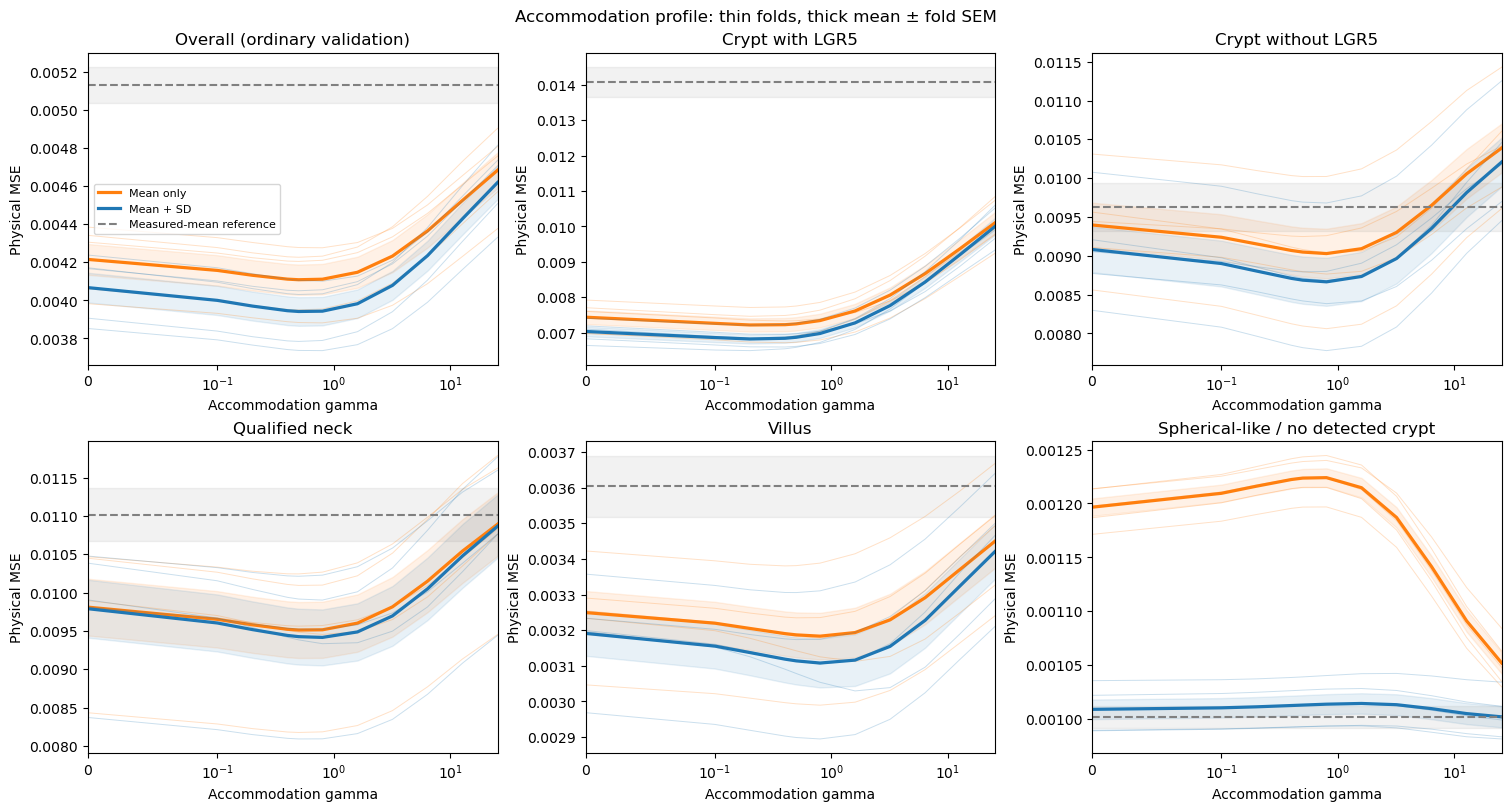

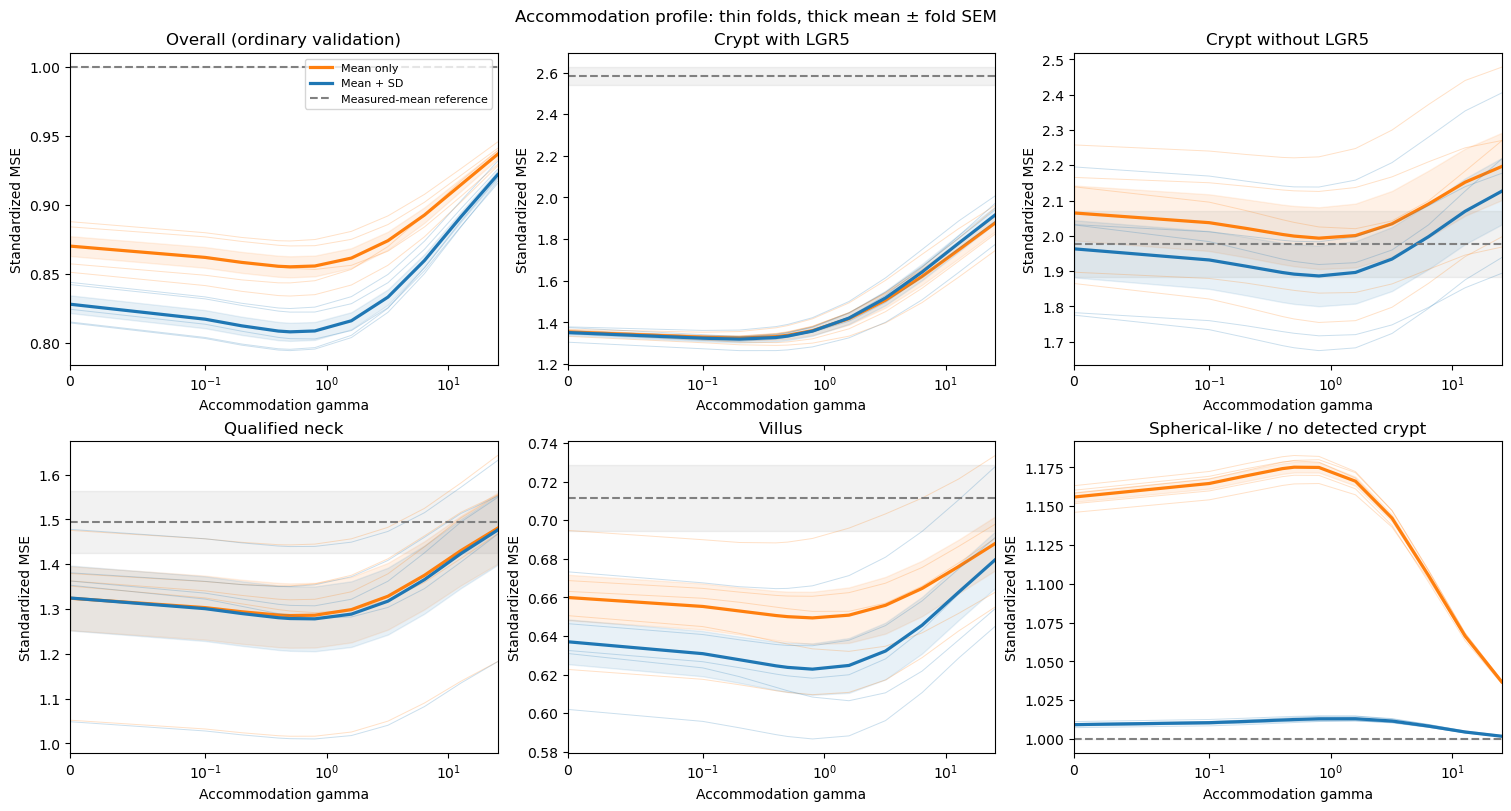

In [4]:
# Overall uses ordinary validation only. The combined region includes the external spherical cohort.
for metric in MSE_METRICS:
    fig,axes=plt.subplots(int(np.ceil(len(REGIONS)/3)),3,figsize=(15,4*int(np.ceil(len(REGIONS)/3))),squeeze=False,layout='constrained')
    for ax,region in zip(axes.flat,REGIONS):
        for mode in TARGET_MODES:
            d=fold_scores[(fold_scores.region==region)&(fold_scores.target_mode==mode)]
            if d.empty:continue
            for _,f in d.groupby('fold'):ax.plot(f.gamma,f[metric],color=mode_colors[mode],lw=.7,alpha=.23)
            curve=d.groupby('gamma')[metric].agg(['mean','sem']);x=curve.index.to_numpy()
            ax.plot(x,curve['mean'],color=mode_colors[mode],lw=2.3,label=mode_labels[mode])
            ax.fill_between(x,curve['mean']-curve['sem'].fillna(0),curve['mean']+curve['sem'].fillna(0),color=mode_colors[mode],alpha=.1)
        baseline=fold_scores[(fold_scores.region==region)&(fold_scores.variant=='measured_mean')][metric]
        if len(baseline):
            ax.axhline(baseline.mean(),ls='--',color='gray',label='Measured-mean reference')
            ax.axhspan(baseline.mean()-(baseline.sem() if len(baseline)>1 else 0),baseline.mean()+(baseline.sem() if len(baseline)>1 else 0),color='gray',alpha=.1)
        ax.set_xscale('symlog',linthresh=.1);ax.set_xlim(0,float(selected.gamma.max()));ax.set(title=region_labels.get(region,region),xlabel='Accommodation gamma',ylabel='Physical MSE' if metric=='mse' else 'Standardized MSE')
    for unused in list(axes.flat)[len(REGIONS):]:unused.set_visible(False)
    axes.flat[0].legend(fontsize=8)
    fig.suptitle('Accommodation profile: thin folds, thick mean ± fold SEM')
    save_figure(fig,f'01_accommodation_{metric}')


## Center preferences and interaction amplitudes
Plot saved coefficients, retaining individual folds. A positive pair coefficient raises the unprojected local preference when its neighboring source identity is present. Center coefficients share an arbitrary common zero. Coefficient variation across folds does not establish causal signaling.

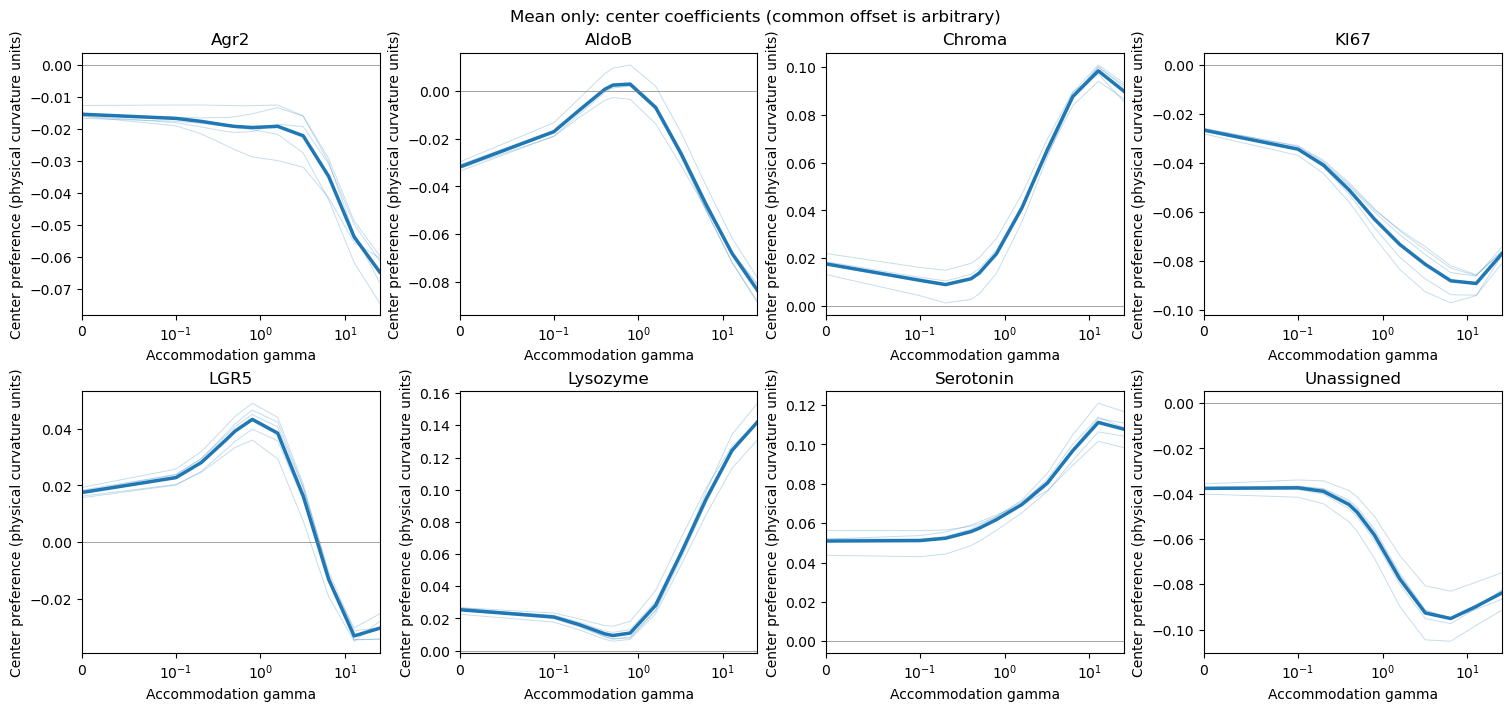

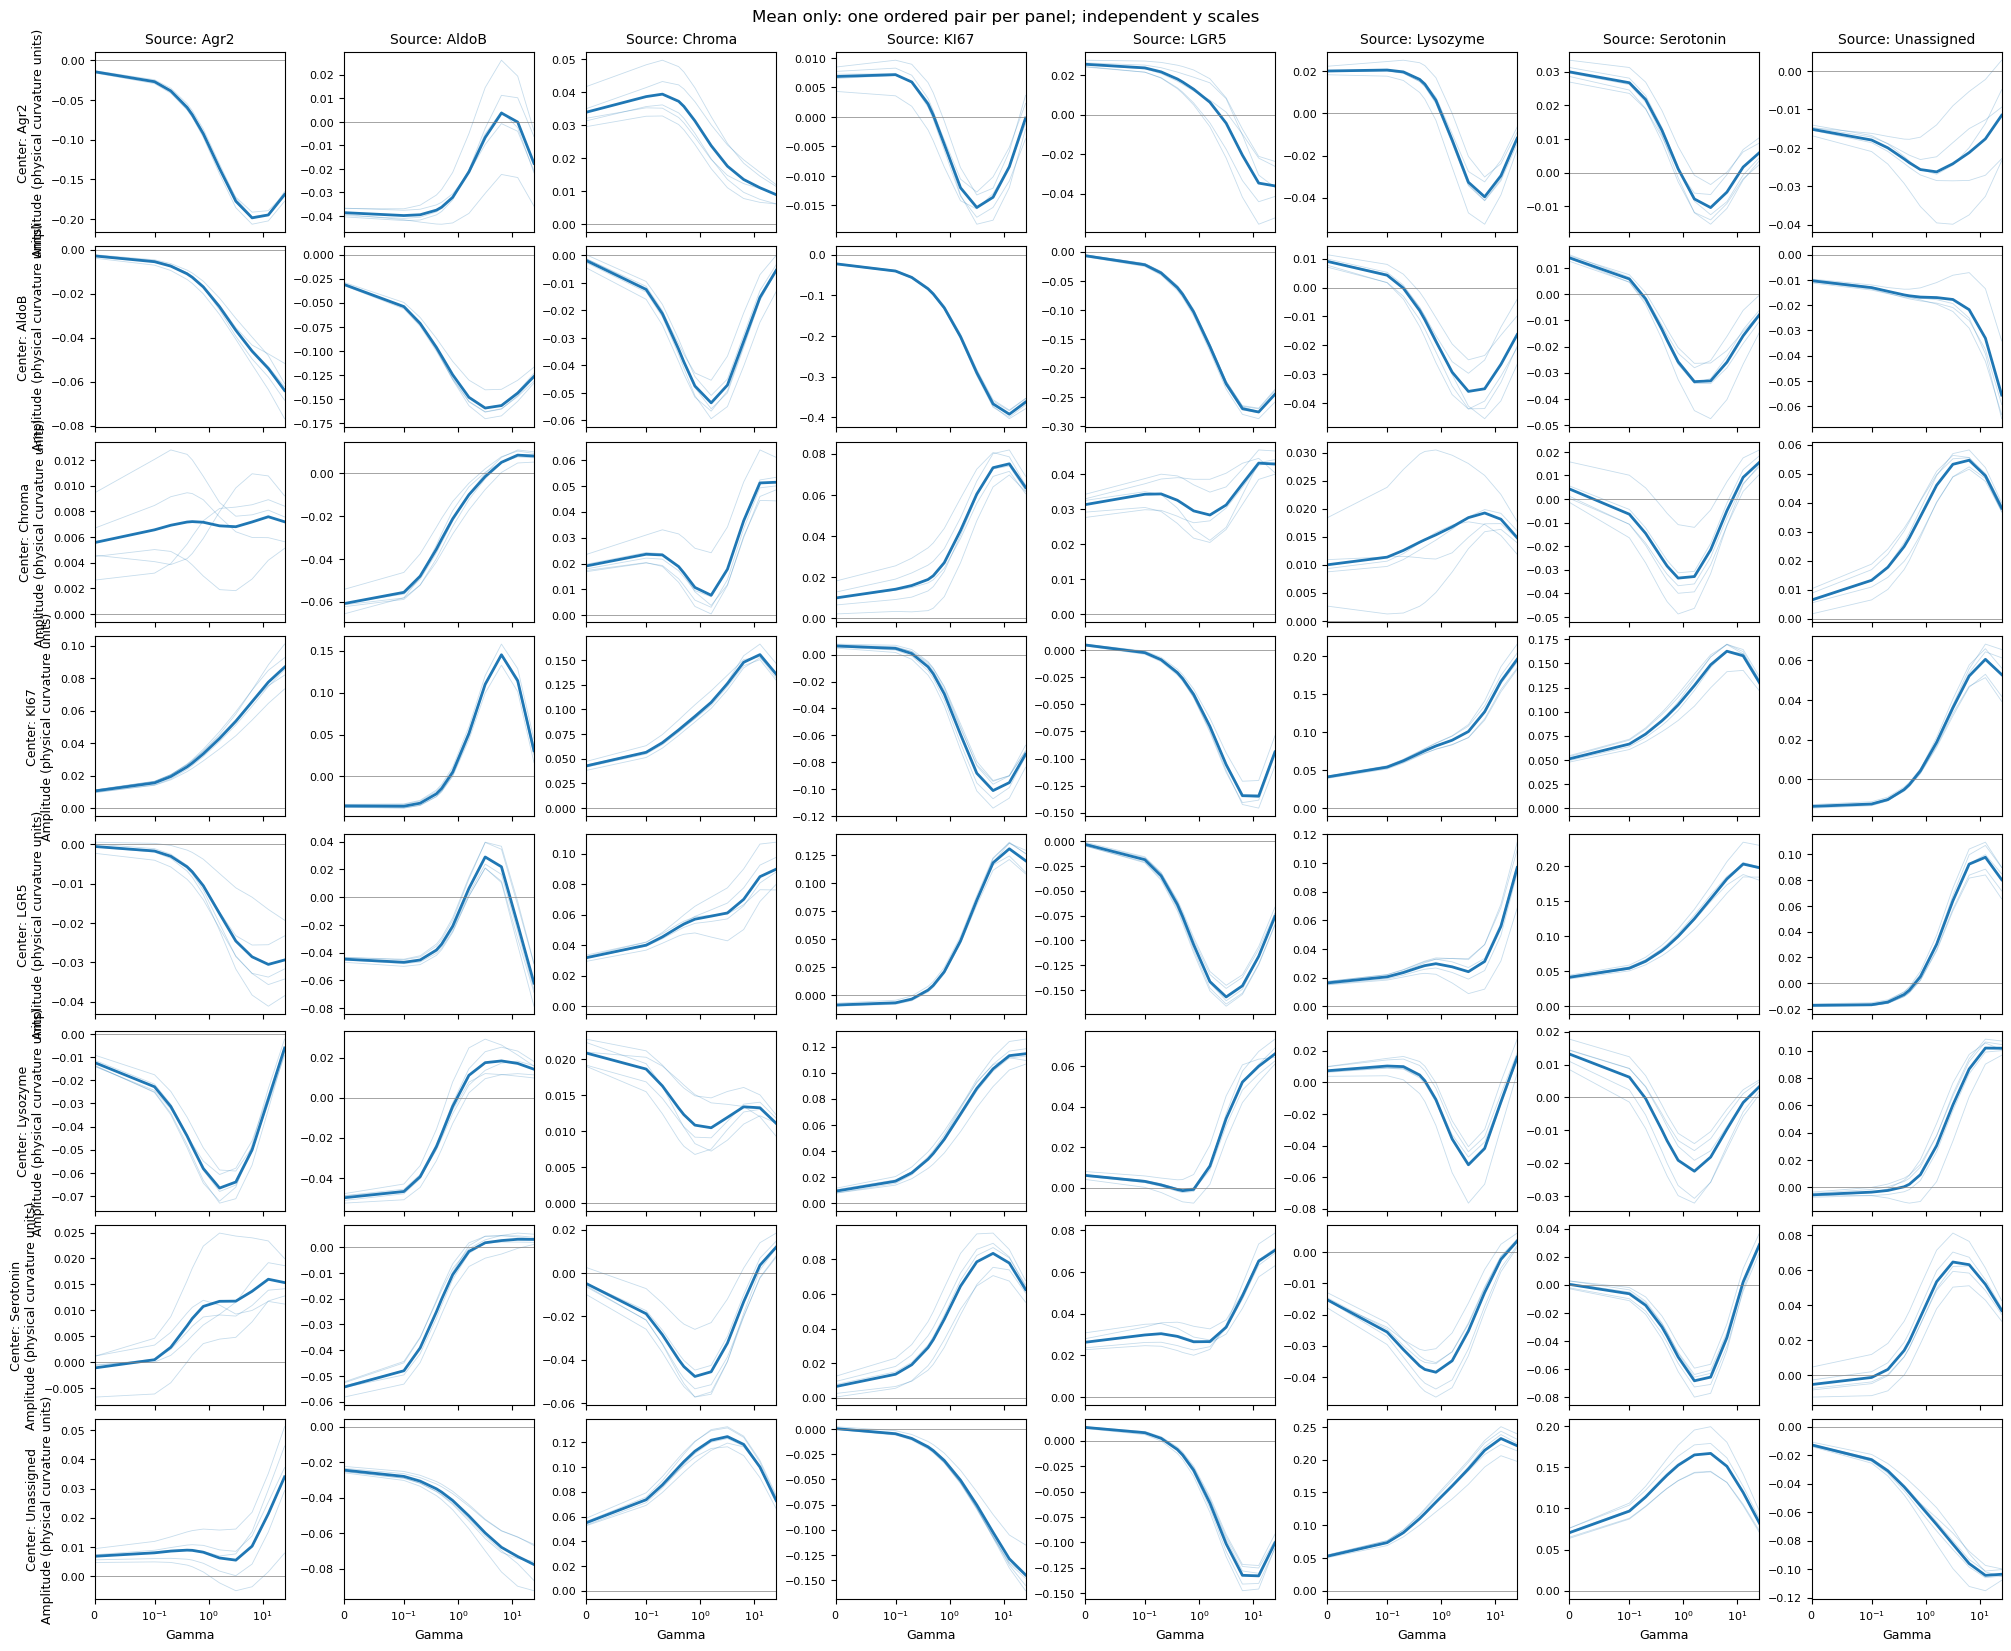

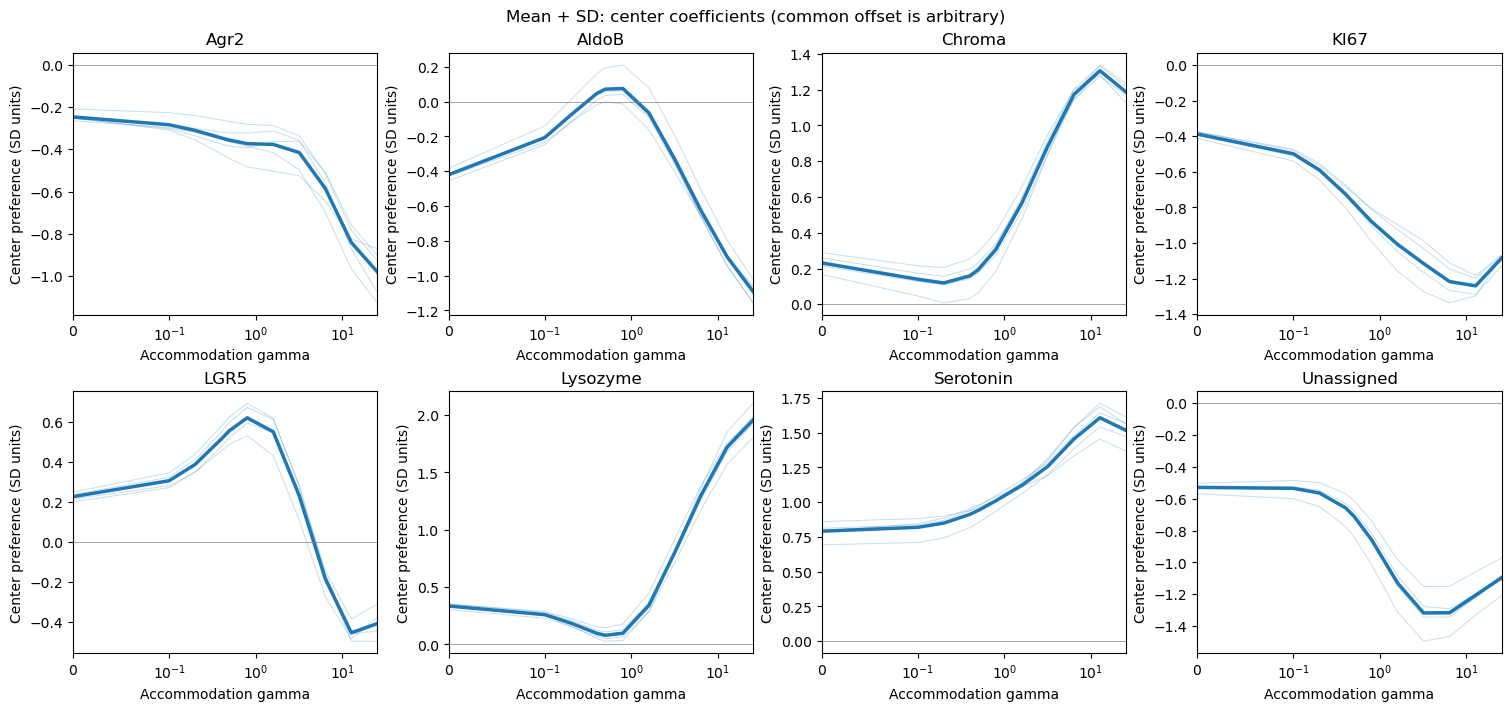

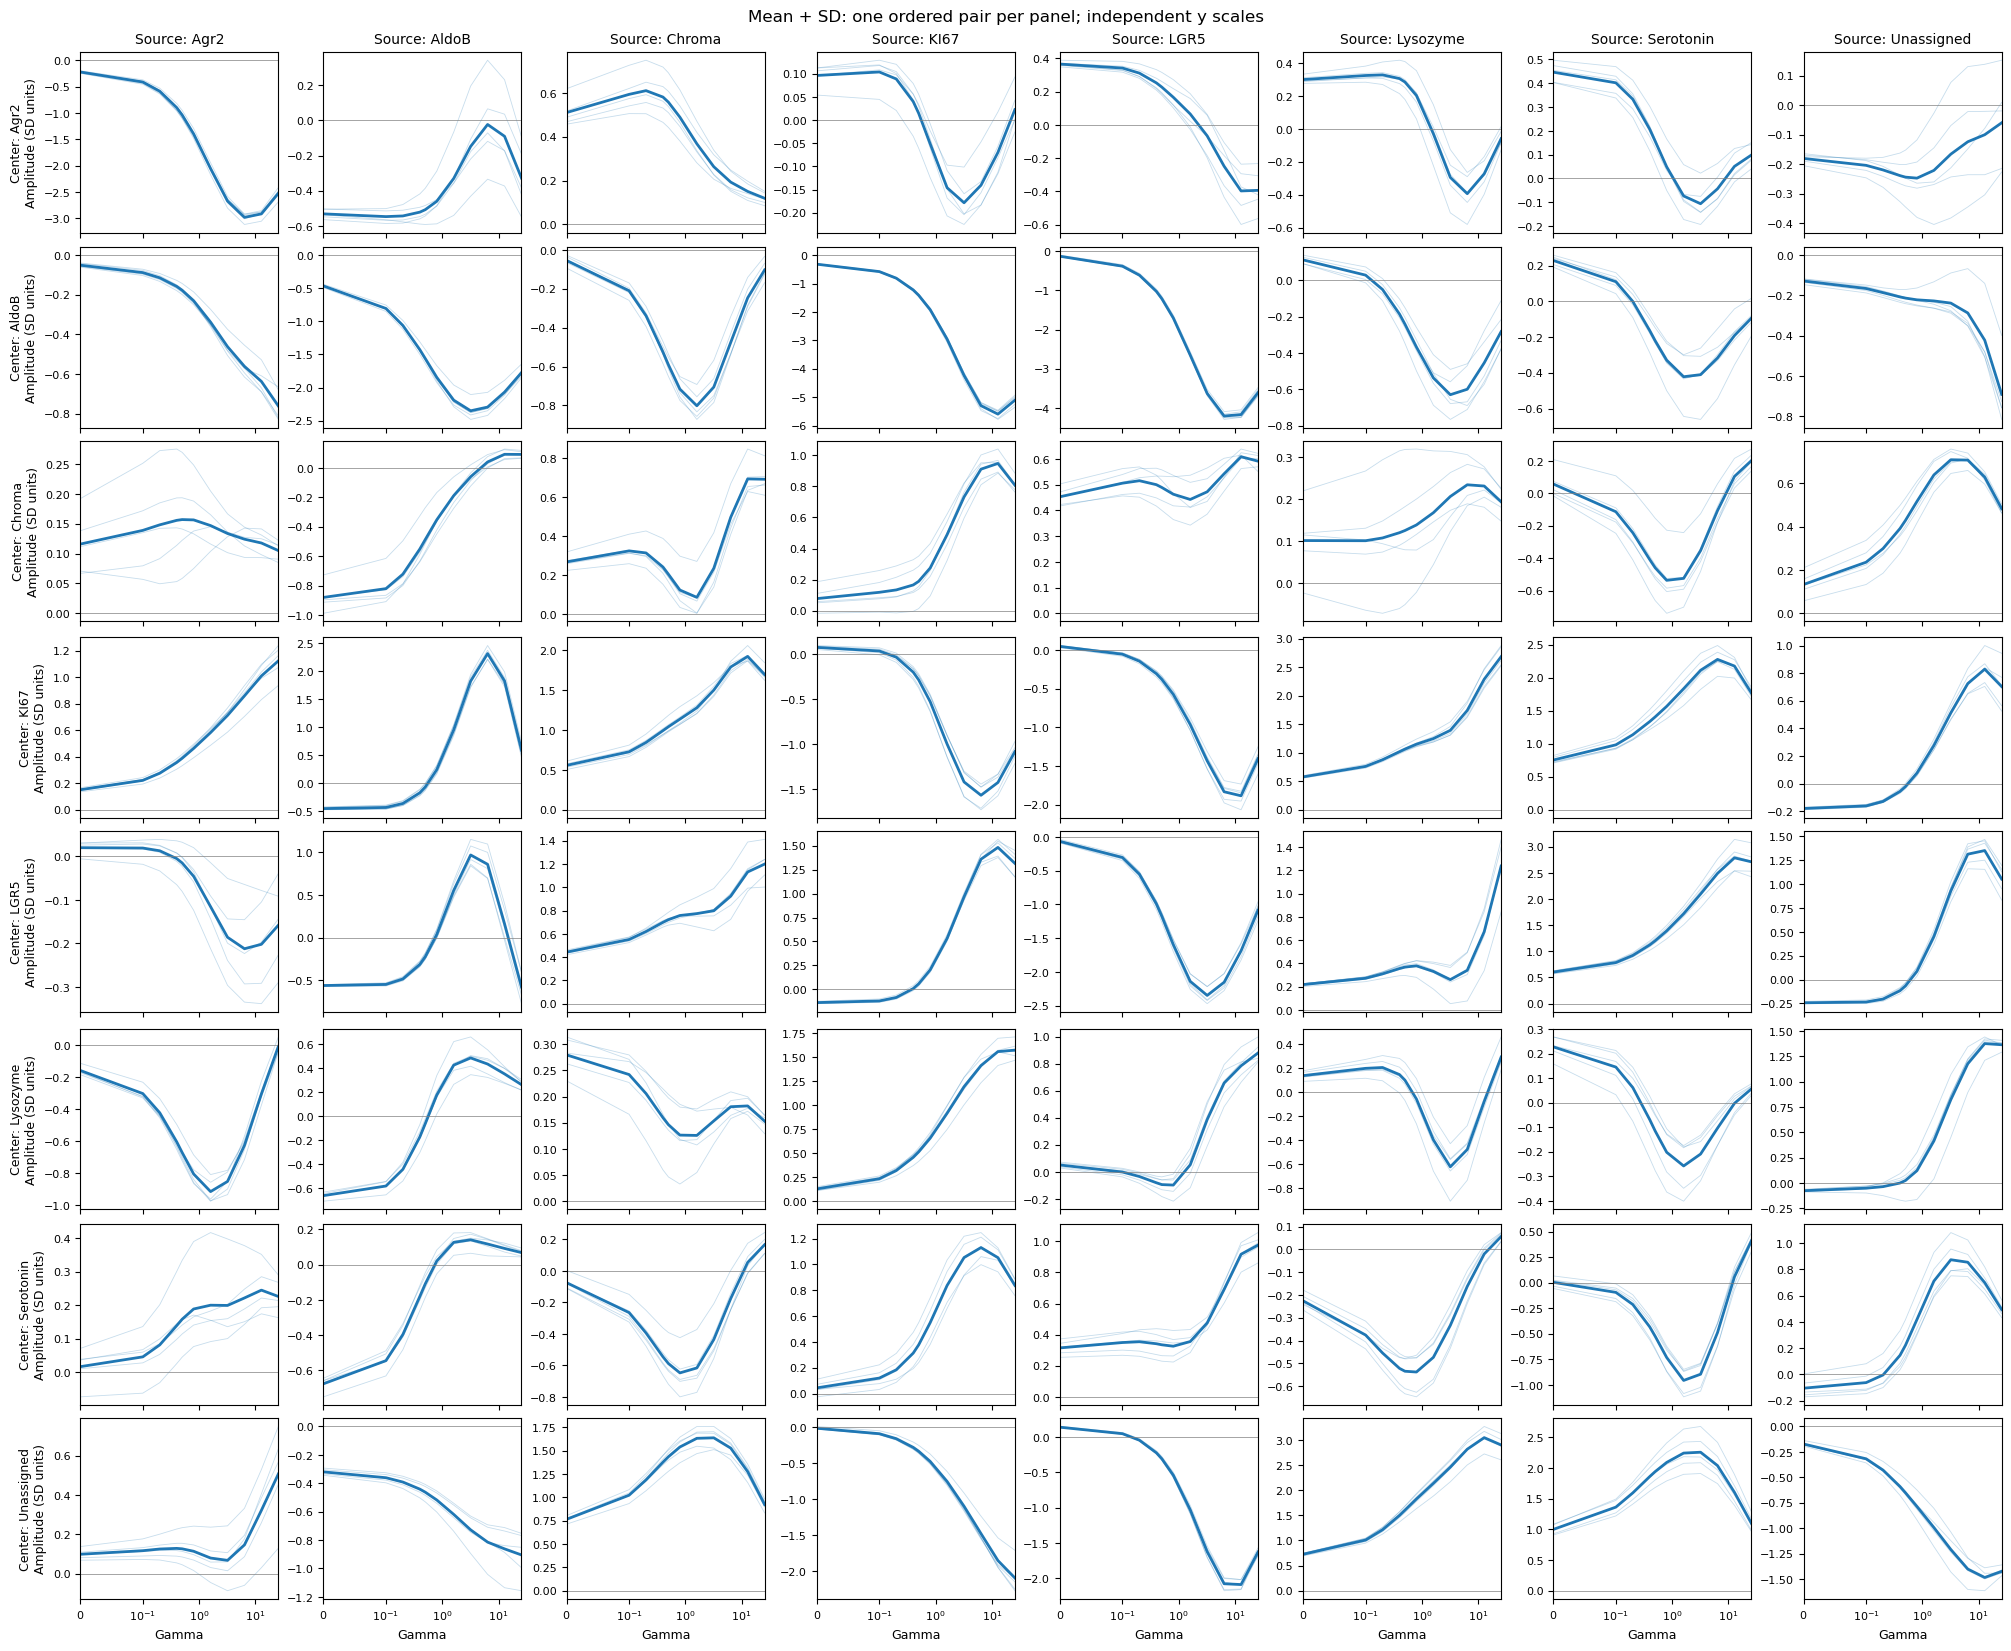

In [5]:
# Separate normalization modes: their coefficient units differ.
for mode in TARGET_MODES:
    unit='SD units' if mode=='standardized' else 'physical curvature units'
    d=coefficients[(coefficients.target_mode==mode)&(coefficients.family=='center')]
    fig,axes=plt.subplots(2,int(np.ceil(len(identities)/2)),figsize=(15,7),layout='constrained')
    for ax,A in zip(axes.flat,identities):
        panel=d[d.recipient==A]
        for _,f in panel.groupby('fold'):ax.plot(f.gamma,f.value,color='tab:blue',lw=.7,alpha=.25)
        mean=panel.groupby('gamma').value.mean();ax.plot(mean.index,mean.values,c='tab:blue',lw=2.5)
        ax.axhline(0,color='gray',lw=.5);ax.set_xscale('symlog',linthresh=.1);ax.set_xlim(0,float(selected.gamma.max()))
        ax.set(title=A,xlabel='Accommodation gamma',ylabel=f'Center preference ({unit})')
    for ax in list(axes.flat)[len(identities):]:ax.set_visible(False)
    fig.suptitle(f'{mode_labels[mode]}: center coefficients (common offset is arbitrary)')
    save_figure(fig,f'02_center_profiles_{mode}')
    pairs=coefficients[(coefficients.target_mode==mode)&(coefficients.family=='interaction')]
    M=len(identities);fig,axes=plt.subplots(M,M,figsize=(2.5*M,2.05*M),sharex=True,layout='constrained')
    for a,A in enumerate(identities):
        for b,B in enumerate(identities):
            ax=axes[a,b];panel=pairs[(pairs.recipient==A)&(pairs.source==B)]
            if panel.empty or not panel.included.any():ax.text(.5,.5,'Excluded',ha='center',transform=ax.transAxes)
            else:
                for _,f in panel.groupby('fold'):ax.plot(f.gamma,f.value,color='tab:blue',alpha=.25,lw=.6)
                mean=panel.groupby('gamma').value.mean();ax.plot(mean.index,mean.values,color='tab:blue',lw=2)
            ax.axhline(0,color='gray',lw=.5);ax.set_xscale('symlog',linthresh=.1);ax.set_xlim(0,float(selected.gamma.max()));ax.tick_params(labelsize=8)
            if a==0:ax.set_title(f'Source: {B}',fontsize=10)
            if b==0:ax.set_ylabel(f'Center: {A}\nAmplitude ({unit})',fontsize=9)
            if a==M-1:ax.set_xlabel('Gamma',fontsize=9)
    fig.suptitle(f'{mode_labels[mode]}: one ordered pair per panel; independent y scales')
    save_figure(fig,f'03_interaction_profiles_{mode}')


## Saved outputs
Figures and machine-readable metrics are written beside the models. This notebook is the analysis record; no long automatically generated report is appended.

In [6]:
(OUTPUT_DIR/'complete.json').write_text(json.dumps(dict(models=len(selected),figures=sorted(p.name for p in OUTPUT_DIR.glob('*.png'))),indent=2))
print('Analysis saved:',OUTPUT_DIR)


Analysis saved: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/energy_model_training/conditional_scan_20261002_162217/analysis/accommodation_profiles
